# Week 9 Phase 1.18B — Prospective finite-pool GPC-SUR

This notebook reads the frozen artifacts. It does not rerun the expensive 200 prospective trajectories.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_18b_prospective_global_gpc_sur_benchmark'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'conduction': 332,
 'historical_changes': [],
 'initial_design_matches': 100,
 'keyholes': 73,
 'outer_runs': 100,
 'p0_complete_paths': 100,
 'p0_paths_length_80': 100,
 'population': 405,
 'published_P0_q20_AULC': 0.844623161764706,
 'repeat_blocks': 20,
 'start_sha': '1e34b4759037d5f3d107781791524853a406a526',
 'status': 'PASS'}

## 1. Three frozen arms

P0 is published M3 probability margin. P1 uses exact enlarged-data Laplace inference while holding the physics mean and Stage-2 kernel fixed. P2 refits only the data-fitted physics mean inside each hypothetical outcome.

In [2]:
display(Markdown((OUT/'sur_protocol.md').read_text()))

# Frozen SUR protocol

For each unqueried outer-training candidate, both hypothetical labels are integrated with its current M3 probability. The current U_n is the common mean p(1-p) over the complete unqueried pool R_n. Each hypothetical future uncertainty is the mean over the remaining pool R_n minus the candidate. P1 freezes the physics mean, outer-pool scaler, and Stage-2 kernel. P2 refits only the revealed-label-fitted physics mean under each hypothetical outcome and freezes the Stage-2 kernel. The actual next-budget M3 model is normally refit. Ties are resolved by smallest population-row index. No hidden label, held-out label, B1, q20, or q30 enters selection.


## 2. Primary q20 result

,contrast,subset,mean_difference,median_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,raw_two_sided_sign_p,bootstrap_draws
0,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,B1_q20,-0.001379,-0.000276,-0.003801,0.000726,9,0,11,0.823803,20000
1,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,B1_q20,-0.004453,-0.006020,-0.010703,0.001627,8,0,12,0.503445,20000
2,P2_PHYSICS_REFIT_SUR-P1_EXACT_FIXED_SUR,B1_q20,-0.003074,-0.006710,-0.009072,0.003056,8,0,12,0.503445,20000


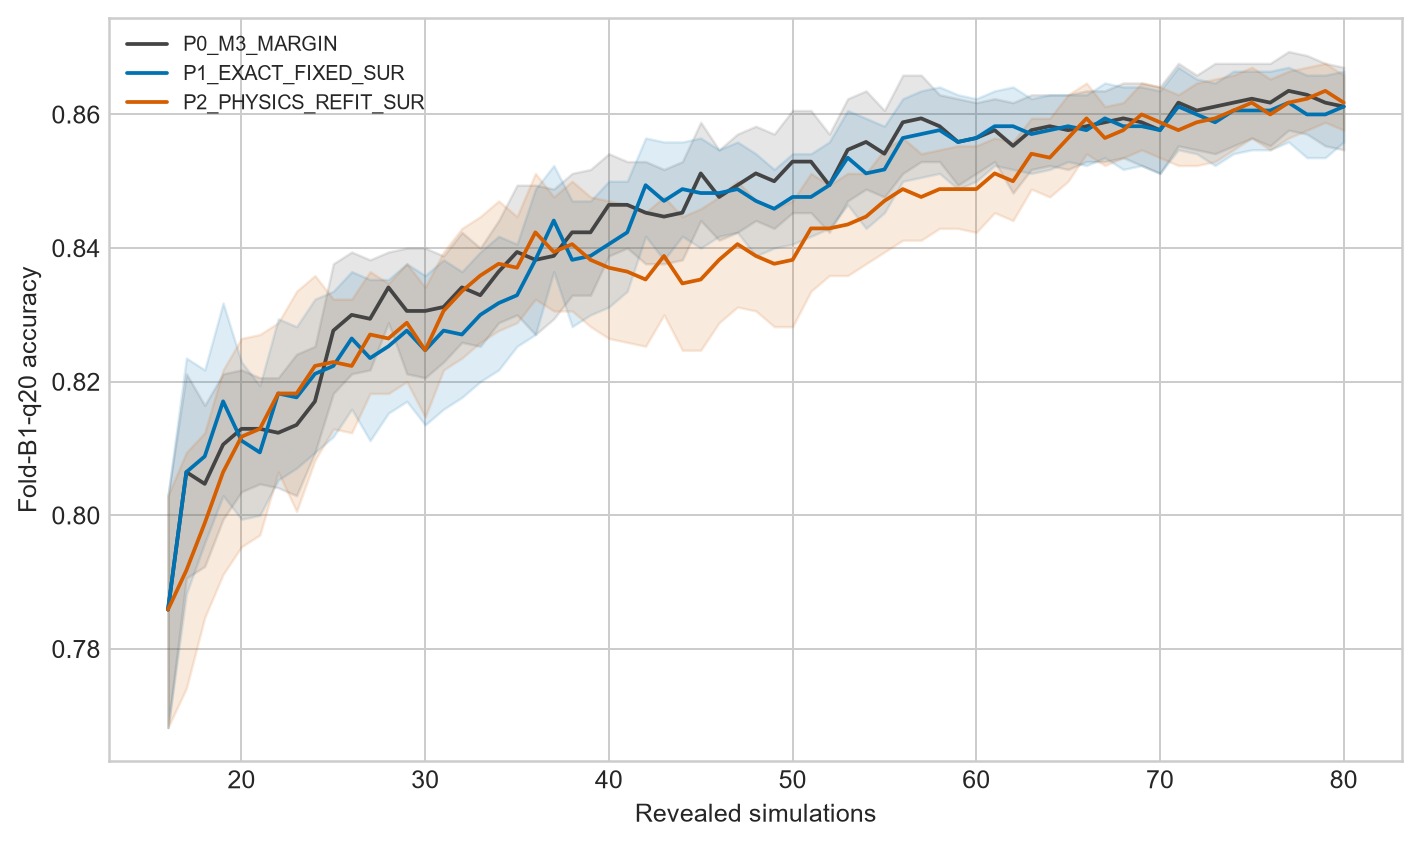

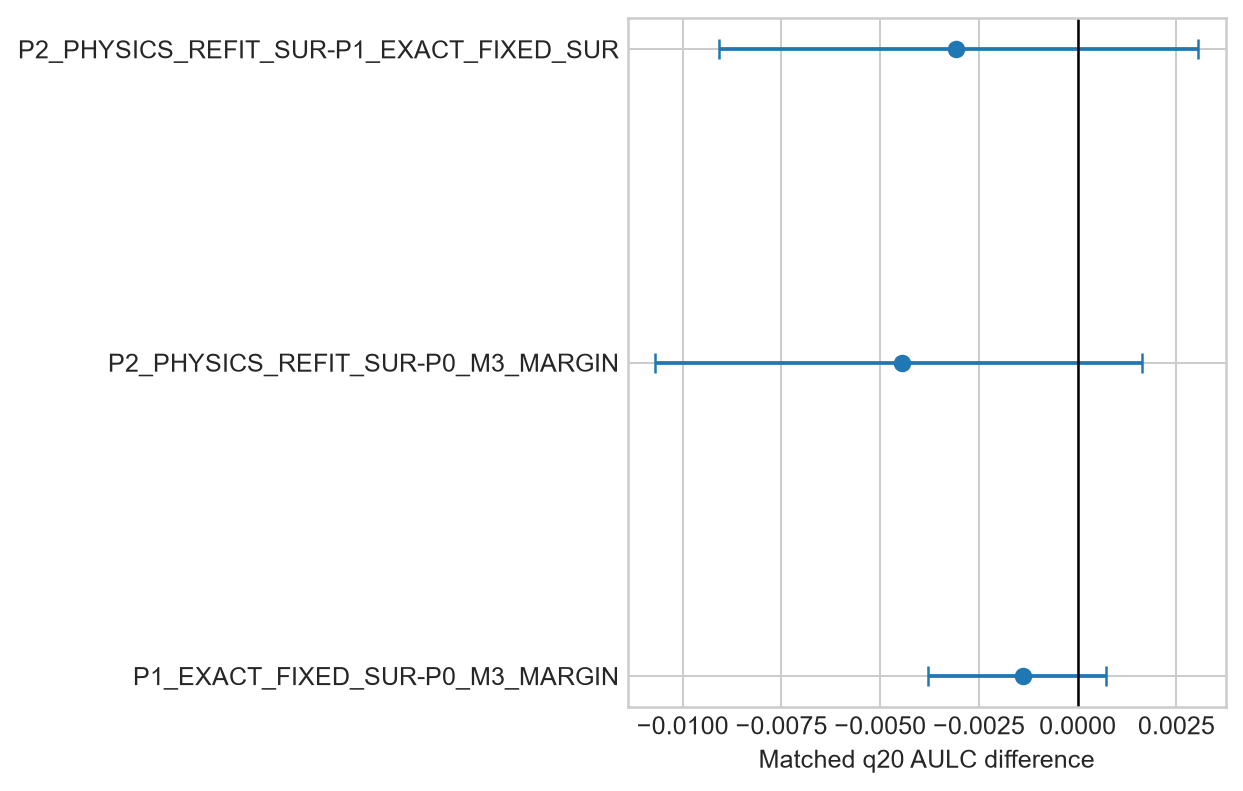

In [3]:
display(pd.read_csv(OUT/'q20_primary_contrasts.csv')); display(Image(filename=str(OUT/'figures'/'01_q20_accuracy_learning_curves.png'))); display(Image(filename=str(OUT/'figures'/'02_paired_q20_aulc_contrasts.png')))

## 3. Budget regions and B40 Keyhole behavior

,region,contrast,mean_difference,median_difference,ci_lower,ci_upper,positive_repeat_blocks
0,EARLY_B16_24,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,0.002169,0.004044,-0.004338,0.008566,11
1,EARLY_B16_24,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,-0.001581,-0.000735,-0.011361,0.008163,10
2,EARLY_B16_24,P2_PHYSICS_REFIT_SUR-P1_EXACT_FIXED_SUR,-0.003750,-0.010662,-0.015074,0.008162,9
3,MID_B25_40,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,-0.003980,-0.003137,-0.008196,0.000098,8
4,MID_B25_40,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,-0.002196,-0.004118,-0.011118,0.006138,7
5,MID_B25_40,P2_PHYSICS_REFIT_SUR-P1_EXACT_FIXED_SUR,0.001784,-0.003725,-0.007078,0.011059,9
6,LATE_B41_80,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,-0.001033,-0.000452,-0.002715,0.000611,7
7,LATE_B41_80,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,-0.005897,-0.008974,-0.012127,0.000747,4
8,LATE_B41_80,P2_PHYSICS_REFIT_SUR-P1_EXACT_FIXED_SUR,-0.004864,-0.006410,-0.010973,0.001735,5
9,BROAD_B16_40,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,-0.001789,-0.001225,-0.006115,0.002157,8


,model,subset,budget,metric,mean,ci_lower,ci_upper,active_keyhole_fraction,cumulative_revealed_keyhole_fraction
0,P0_M3_MARGIN,B1_q20,40,balanced_accuracy,0.827068,0.817583,0.836057,0.469167,0.41075
1,P0_M3_MARGIN,B1_q20,40,keyhole_recall,0.748738,0.729702,0.766353,0.469167,0.41075
2,P1_EXACT_FIXED_SUR,B1_q20,40,balanced_accuracy,0.818377,0.805634,0.830165,0.482083,0.41850
3,P1_EXACT_FIXED_SUR,B1_q20,40,keyhole_recall,0.739679,0.714821,0.763845,0.482083,0.41850
4,P2_PHYSICS_REFIT_SUR,B1_q20,40,balanced_accuracy,0.817482,0.805631,0.828726,0.425833,0.38475
5,P2_PHYSICS_REFIT_SUR,B1_q20,40,keyhole_recall,0.744714,0.720622,0.768147,0.425833,0.38475


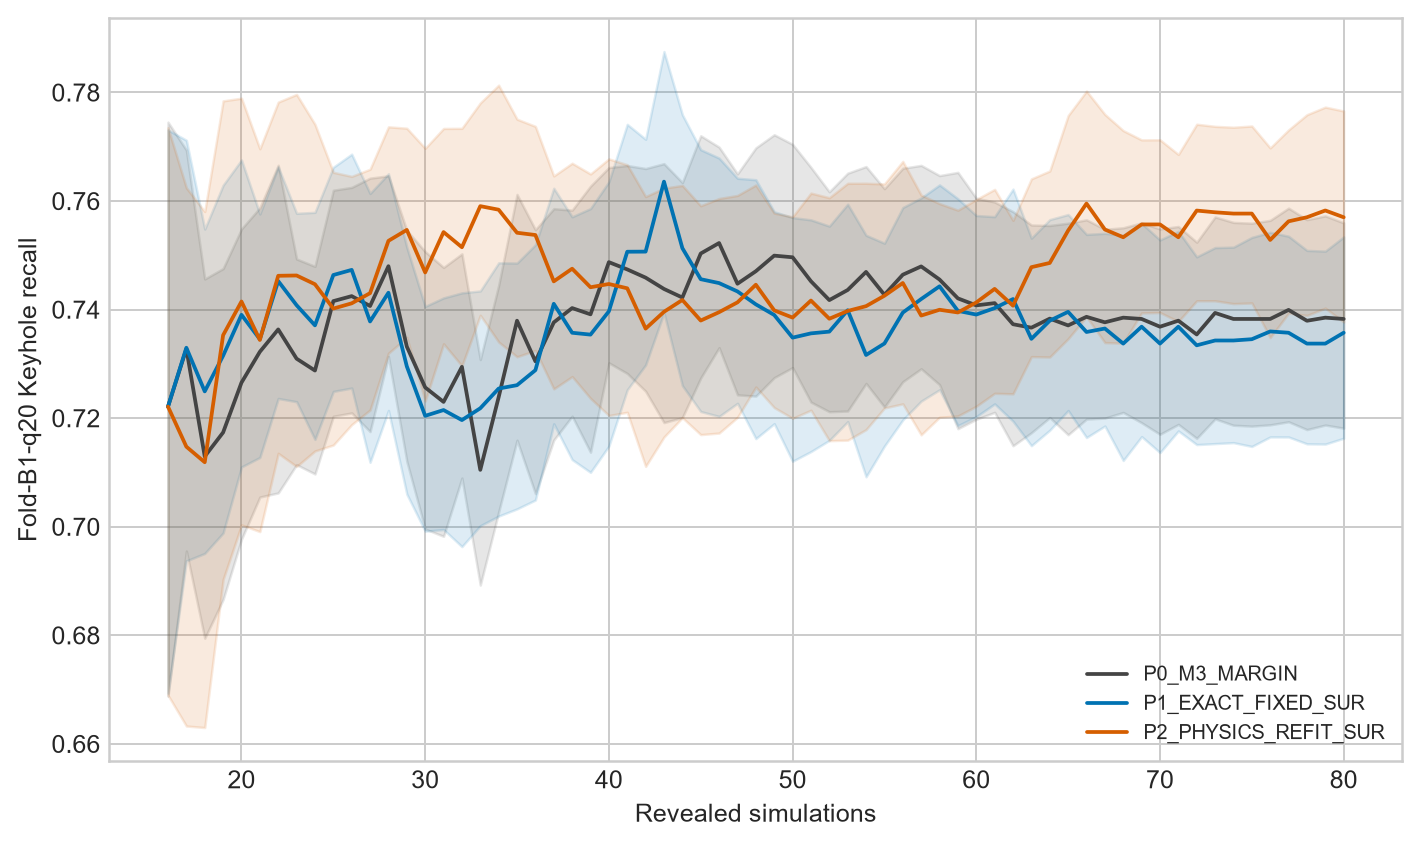

In [4]:
display(pd.read_csv(OUT/'q20_budget_region_contrasts.csv')); display(pd.read_csv(OUT/'b40_keyhole_diagnostics.csv')); display(Image(filename=str(OUT/'figures'/'03_q20_keyhole_recall.png')))

## 4. Sample efficiency and paths

,model,threshold,n_runs,reached_count,reached_fraction,median_first_hit_budget_reached_only
0,P0_M3_MARGIN,0.80,100,95,0.95,16.0
1,P0_M3_MARGIN,0.82,100,95,0.95,16.0
2,P0_M3_MARGIN,0.84,100,79,0.79,18.0
3,P1_EXACT_FIXED_SUR,0.80,100,95,0.95,16.0
4,P1_EXACT_FIXED_SUR,0.82,100,95,0.95,16.0
5,P1_EXACT_FIXED_SUR,0.84,100,79,0.79,18.0
6,P2_PHYSICS_REFIT_SUR,0.80,100,93,0.93,16.0
7,P2_PHYSICS_REFIT_SUR,0.82,100,93,0.93,16.0
8,P2_PHYSICS_REFIT_SUR,0.84,100,76,0.76,18.0


,threshold,contrast,sign_convention,common_attained_runs,mean_label_difference,median_label_difference,ci_lower,ci_upper
0,0.80,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,SUR minus Margin; negative means fewer labels,95,-0.135000,0.000000,-0.405000,0.045000
1,0.80,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,SUR minus Margin; negative means fewer labels,93,1.350000,0.450000,0.007500,2.767500
2,0.82,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,SUR minus Margin; negative means fewer labels,95,-0.135000,0.000000,-0.400000,0.045000
3,0.82,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,SUR minus Margin; negative means fewer labels,93,1.350000,0.450000,0.010000,2.770000
4,0.84,P1_EXACT_FIXED_SUR-P0_M3_MARGIN,SUR minus Margin; negative means fewer labels,77,0.983333,0.000000,-0.110000,2.357500
5,0.84,P2_PHYSICS_REFIT_SUR-P0_M3_MARGIN,SUR minus Margin; negative means fewer labels,74,5.144167,4.791667,2.374979,8.002542


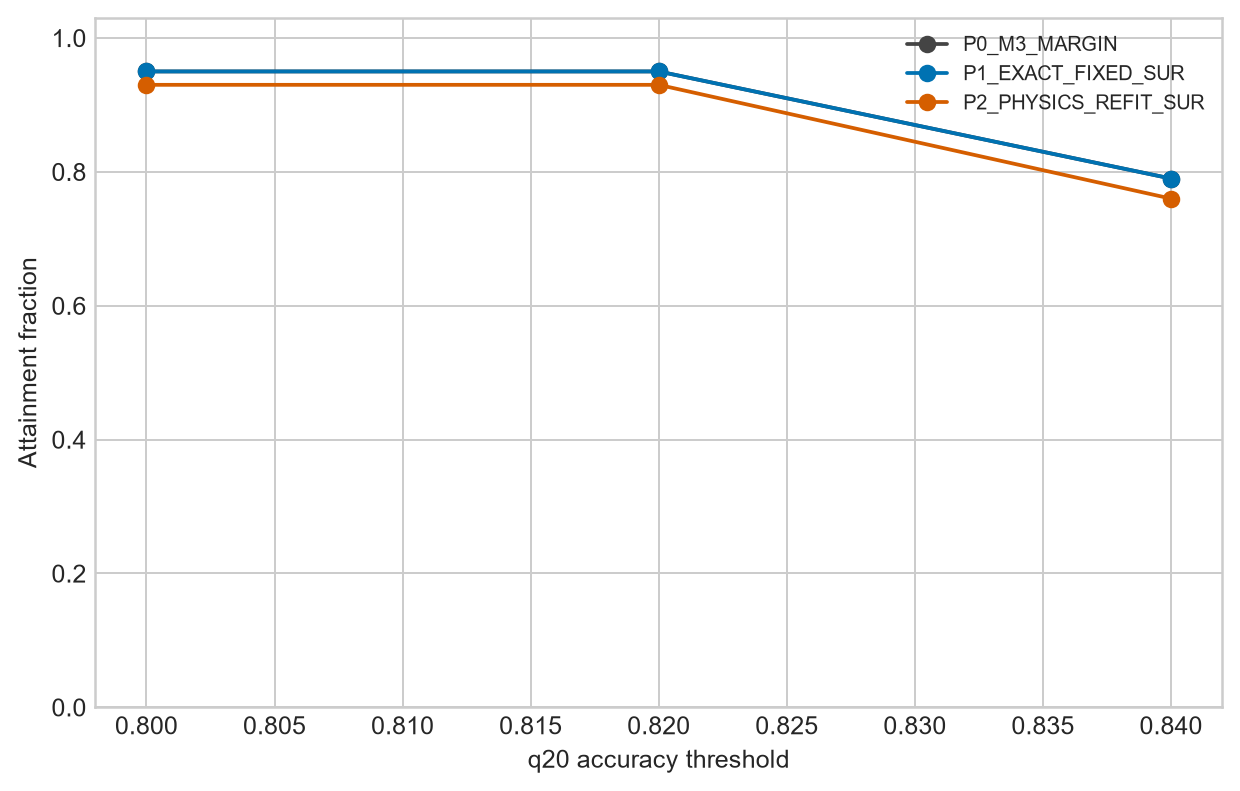

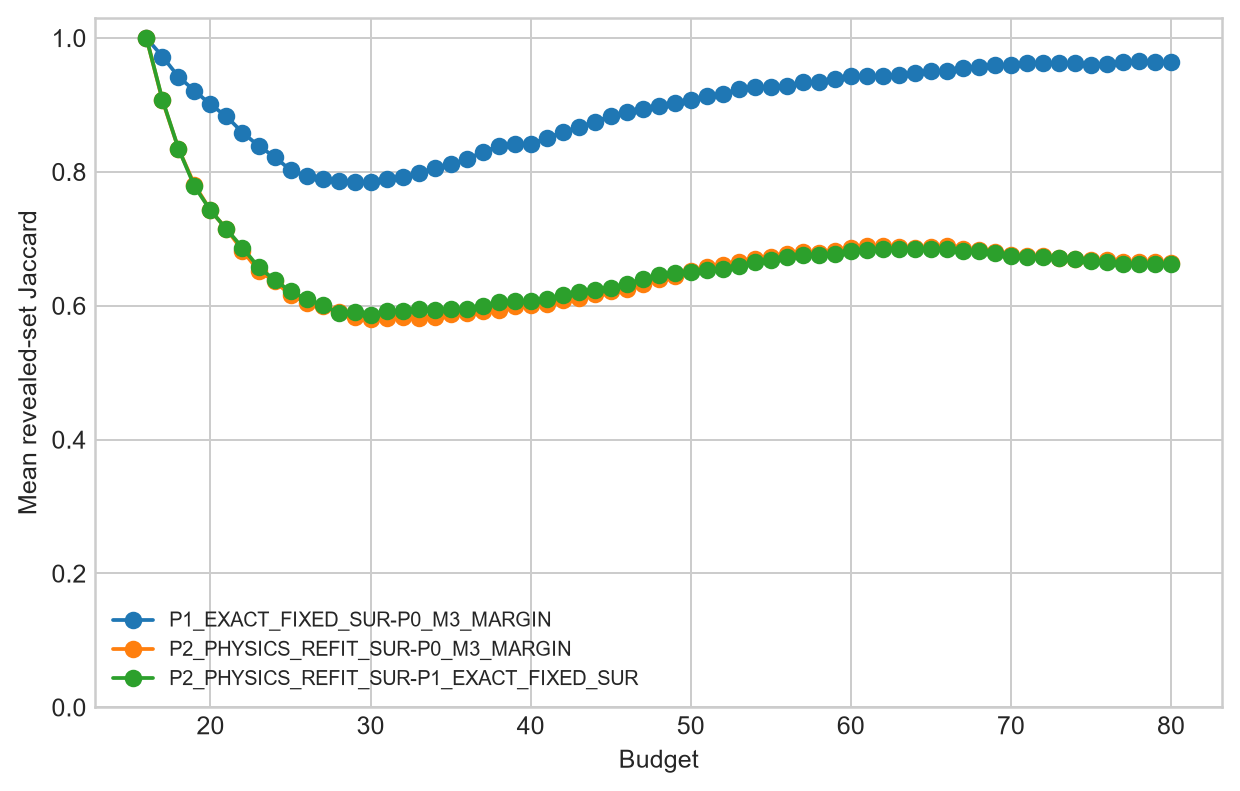

In [5]:
display(pd.read_csv(OUT/'sample_efficiency_thresholds.csv')); display(pd.read_csv(OUT/'sample_efficiency_contrasts.csv')); display(Image(filename=str(OUT/'figures'/'04_sample_efficiency_thresholds.png'))); display(Image(filename=str(OUT/'figures'/'05_path_overlap.png')))

## 5. Global uncertainty and physics-refit mechanism

,arm,budget,candidate_count,hypothetical_failures,fallback_count,constant_score_events,median_score_range,median_top1_top2_gap,mean_near_tied_fraction,mean_scoring_seconds
0,P1_EXACT_FIXED_SUR,16,308.0,0,0,0,0.000814,0.000008,0.003247,3.155440
1,P1_EXACT_FIXED_SUR,17,307.0,0,0,0,0.000816,0.000016,0.004300,3.205420
2,P1_EXACT_FIXED_SUR,18,306.0,0,0,0,0.000818,0.000025,0.003268,3.245521
3,P1_EXACT_FIXED_SUR,19,305.0,0,0,0,0.000814,0.000021,0.003279,3.318050
4,P1_EXACT_FIXED_SUR,20,304.0,0,0,0,0.000801,0.000013,0.006250,4.478251
...,...,...,...,...,...,...,...,...,...,...
123,P2_PHYSICS_REFIT_SUR,75,249.0,0,0,0,0.000305,0.000004,0.008394,7.798682
124,P2_PHYSICS_REFIT_SUR,76,248.0,0,0,0,0.000275,0.000005,0.006250,7.842909
125,P2_PHYSICS_REFIT_SUR,77,247.0,0,0,0,0.000246,0.000004,0.010121,7.792671
126,P2_PHYSICS_REFIT_SUR,78,246.0,0,0,0,0.000249,0.000005,0.010610,8.004539


,run_id,budget,common_candidate_count,score_spearman,top1_agreement,top5_jaccard
0,w85__r01_f01,16,308,0.978658,False,0.428571
1,w85__r01_f01,17,306,0.920265,False,0.428571
2,w85__r01_f01,18,304,0.985436,False,0.428571
3,w85__r01_f01,19,302,0.912794,False,0.111111
4,w85__r01_f01,20,301,0.981585,False,0.428571
...,...,...,...,...,...,...
6395,w85__r20_f05,75,230,0.056081,False,0.111111
6396,w85__r20_f05,76,228,0.092143,False,0.111111
6397,w85__r20_f05,77,228,0.151750,False,0.250000
6398,w85__r20_f05,78,227,0.200212,True,0.250000


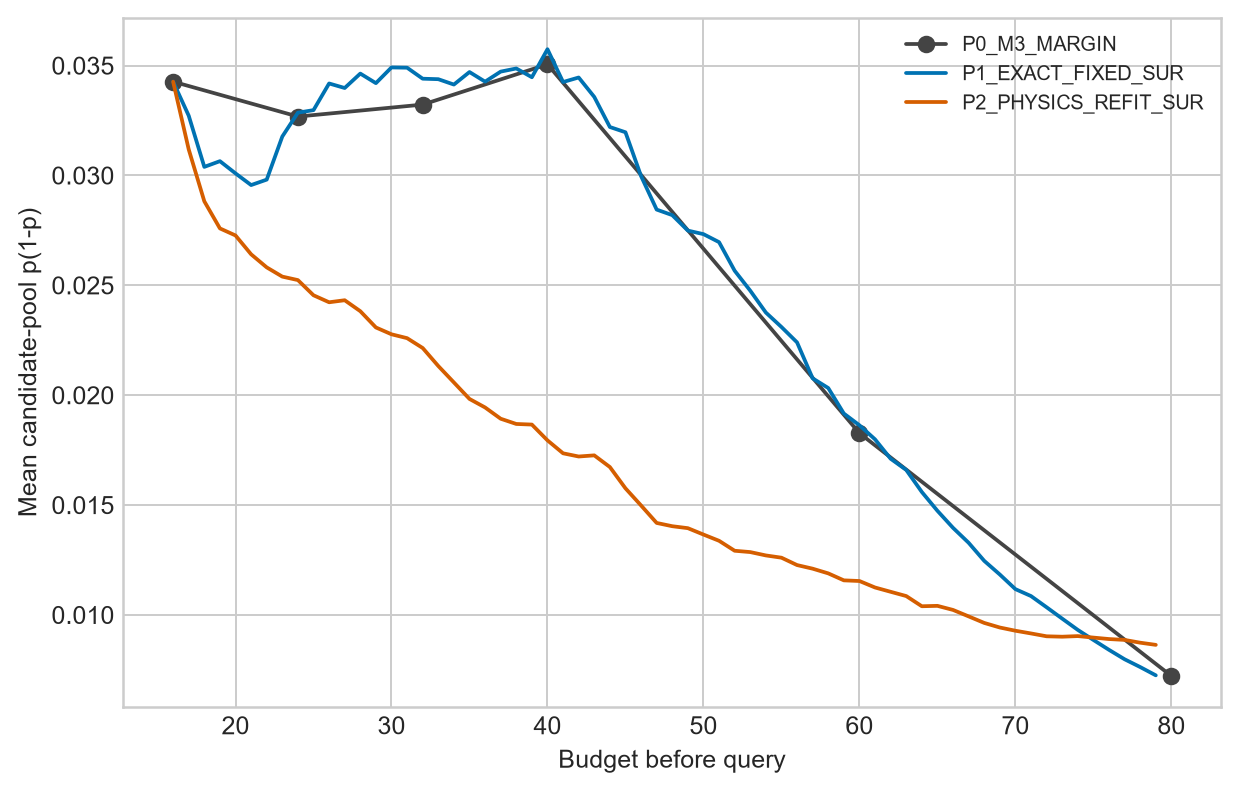

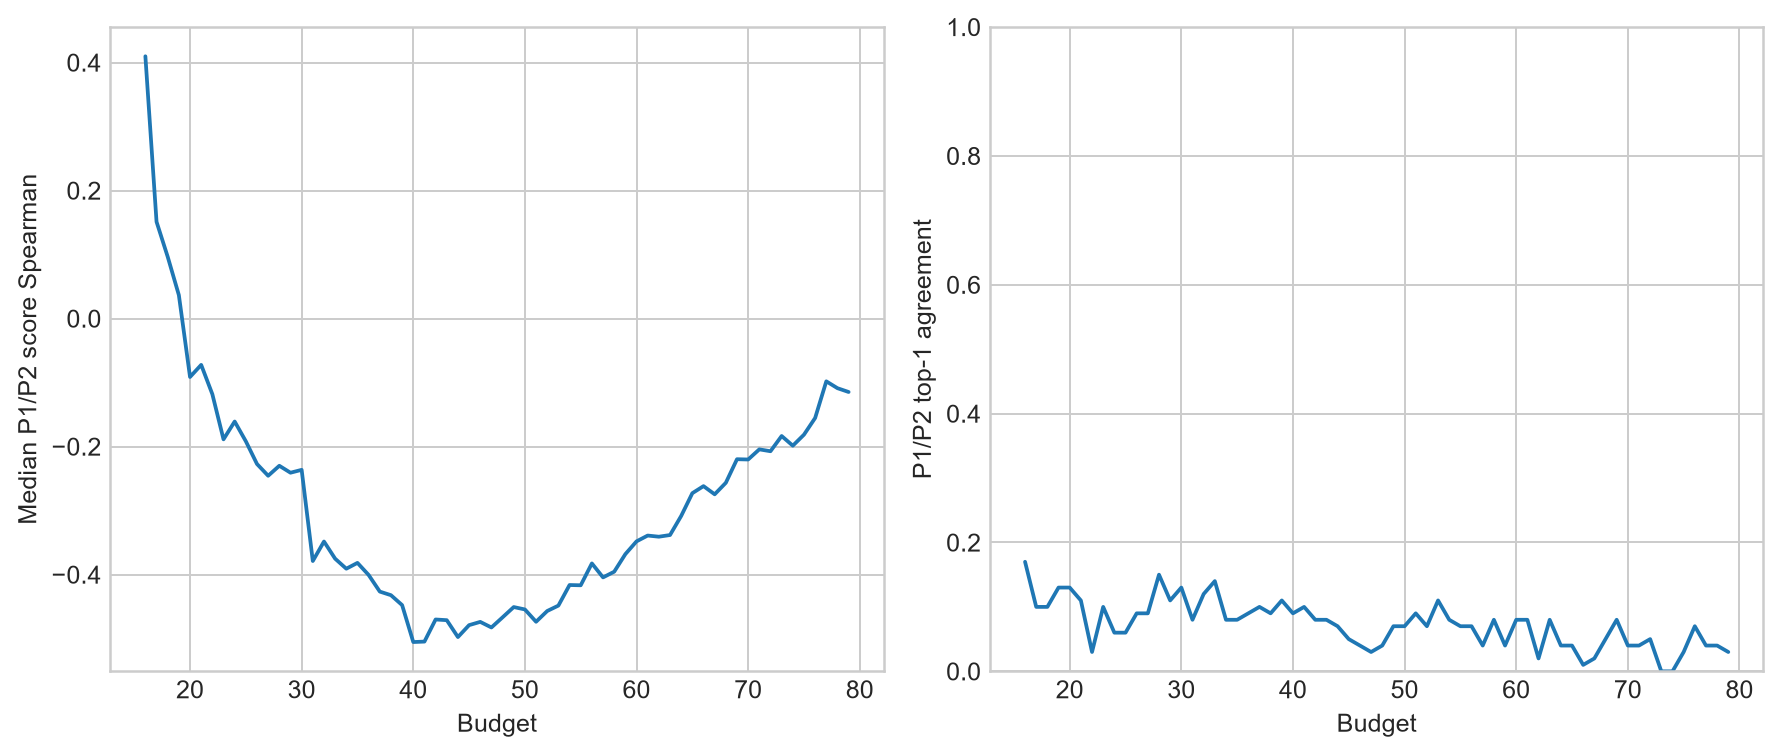

In [6]:
display(pd.read_csv(OUT/'sur_numerical_diagnostics.csv')); display(pd.read_csv(OUT/'physics_refit_mechanism.csv')); display(Image(filename=str(OUT/'figures'/'06_global_sur_evolution.png'))); display(Image(filename=str(OUT/'figures'/'07_physics_refit_mechanism.png')))

## 6. Safe conclusion

In [7]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_18B_ONE_PAGE.md').read_text()))

# Supervisor one-page â€” Phase 1.18B

- **Question:** Does global finite-pool predictive-uncertainty reduction beat local M3 probability margin?
- **P0 / P1 / P2 q20 AULC:** 0.844623 / 0.843244 / 0.840170.
- **Primary P1âˆ’P0:** -0.001379, 95% repeat-block CI [-0.003801, +0.000726].
- **Physics-refit P2âˆ’P0:** -0.004453, CI [-0.010703, +0.001627].
- **P2âˆ’P1:** -0.003074, CI [-0.009072, +0.003056].
- **Holm-adjusted primary p-values:** P1âˆ’P0 1; P2âˆ’P0 1.
- **B40 q20 Keyhole recall:** P0/P1/P2 = 0.7487/0.7397/0.7447.
- **Decisions:** `GLOBAL_SUR_NO_GAIN`; `PHYSICS_REFIT_SUR_CHANGES_PATH_ONLY`; `LABEL_SAVING_NOT_SUPPORTED`.
- **Numerics:** 0 failed hypothetical solves; 0 disclosed deterministic retries.
- **Safe interpretation:** the benchmark isolates the acquisition path under the same M3 evaluator. q30, individual budgets, and path diversity cannot override the q20 primary result.
- **Stopping rule:** this closes the planned Week 9 acquisition search unless validation exposes an implementation error.
